# 05 - Logistic Regression

Muc tieu: GridSearchCV cho LogisticRegression, danh gia tren validation set, luu `models/lr_model.pkl`.

In [1]:
import pandas as pd
import numpy as np
import time
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_style("whitegrid")

In [2]:
X_train_tfidf = joblib.load('../data/X_train_tfidf.pkl')
X_val_tfidf = joblib.load('../data/X_val_tfidf.pkl')
y_train = joblib.load('../data/y_train.pkl')
y_val = joblib.load('../data/y_val.pkl')

In [3]:
# Khởi tạo mô hình Logistic Regression căn bản
lr = LogisticRegression(max_iter=1000, random_state=42)

# Định nghĩa không gian tham số tìm kiếm
param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

# Khởi tạo GridSearchCV với K-Fold Cross Validation
grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("Đang chạy GridSearchCV...")
start_time = time.time()
grid_search.fit(X_train_tfidf, y_train)
print(f"Hoàn thành Grid Search sau {time.time() - start_time:.2f} giây.")

print("Tham số tốt nhất tìm được:", grid_search.best_params_)
print("F1-Score tốt nhất trên Cross-Validation:", grid_search.best_score_)

Đang chạy GridSearchCV...
Fitting 5 folds for each of 5 candidates, totalling 25 fits


d:\PROJECT_GIT\Fake-News-Detection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Hoàn thành Grid Search sau 17.19 giây.
Tham số tốt nhất tìm được: {'C': 10.0, 'penalty': 'l2', 'solver': 'lbfgs'}
F1-Score tốt nhất trên Cross-Validation: 0.9823505751875876


===== BÁO CÁO PHÂN LOẠI (VAL SET) =====
               precision    recall  f1-score   support

Real News (0)       0.99      0.99      0.99      3179
Fake News (1)       0.99      0.98      0.99      2619

     accuracy                           0.99      5798
    macro avg       0.99      0.99      0.99      5798
 weighted avg       0.99      0.99      0.99      5798



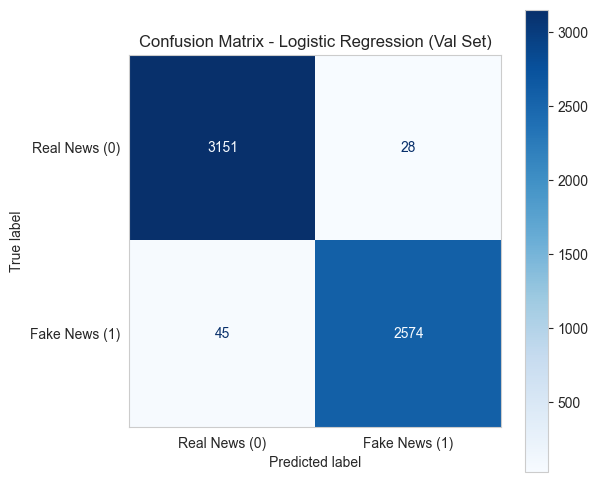

In [4]:
best_lr_model = grid_search.best_estimator_

y_pred = best_lr_model.predict(X_val_tfidf)

# In báo cáo chi tiết (Precision, Recall, F1-Score)
print("===== BÁO CÁO PHÂN LOẠI (VAL SET) =====")
print(classification_report(y_val, y_pred, target_names=['Real News (0)', 'Fake News (1)']))

# Vẽ Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real News (0)', 'Fake News (1)'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Confusion Matrix - Logistic Regression (Val Set)")
plt.grid(False)
plt.show()

C:\Users\Nguyen Xuan\AppData\Local\Temp\ipykernel_6428\1453458342.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_fake, x='Coefficient', y='Feature', palette='Reds_r')
C:\Users\Nguyen Xuan\AppData\Local\Temp\ipykernel_6428\1453458342.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_real, x=top_real['Coefficient'].abs(), y='Feature', palette='Blues_r')


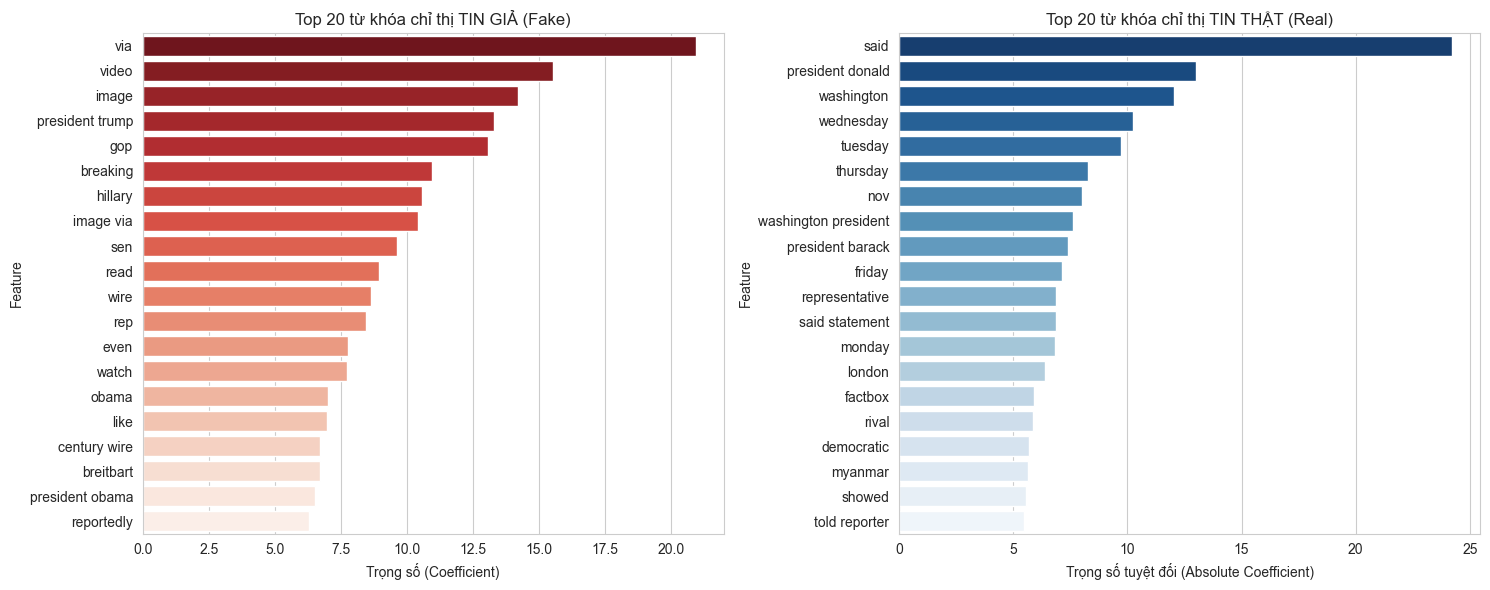

In [5]:
# Tải vectorizer để lấy tên của các đặc trưng (từ vựng)
vectorizer = joblib.load('../models/tfidf_vectorizer.pkl')
feature_names = np.array(vectorizer.get_feature_names_out())


coefs = best_lr_model.coef_[0]

# DataFrame chứa từ khóa và hệ số tương ứng
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefs
})

top_fake = coef_df.sort_values(by='Coefficient', ascending=False).head(20)
top_real = coef_df.sort_values(by='Coefficient', ascending=True).head(20)

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=top_fake, x='Coefficient', y='Feature', palette='Reds_r')
plt.title("Top 20 từ khóa chỉ thị TIN GIẢ (Fake)")
plt.xlabel("Trọng số (Coefficient)")

plt.subplot(1, 2, 2)
sns.barplot(data=top_real, x=top_real['Coefficient'].abs(), y='Feature', palette='Blues_r')
plt.title("Top 20 từ khóa chỉ thị TIN THẬT (Real)")
plt.xlabel("Trọng số tuyệt đối (Absolute Coefficient)")

plt.tight_layout()
plt.show()

In [6]:
# Lưu mô hình Logistic Regression
model_path = '../models/lr_model.pkl'
joblib.dump(best_lr_model, model_path)
print(f"Đã lưu mô hình Logistic Regression thành công tại: {model_path}")

Đã lưu mô hình Logistic Regression thành công tại: ../models/lr_model.pkl
